In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, matthews_corrcoef
)
from sklearn.pipeline import Pipeline
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('All libraries imported successfully')

All libraries imported successfully


In [18]:
df = pd.read_excel('MLdata.xlsx')
print('Original Dataset Shape:', df.shape)
df.head()

Original Dataset Shape: (107, 13)


,Name,Grade,StudyHours,StudyDays,LastMinuteStudy,Revision,Attendance,SleepHours,Distraction,DistractionType,MobileHours,Score,HabitImpact
0,Sampreetha,MSc,1–2 hours,3–4 days,Always,Before exams only,75–90%,7–8 hours,Sometimes,Mobile phone,More than 4 hours,80.0,Agree
1,Samrudhi Ramesh,MSc,Less than 1 hour,1–2 days,Always,Rarely,75–90%,7–8 hours,Often,Mobile phone,More than 4 hours,88.0,Agree
2,Shraddha Shetty,MCA,2–4 hours,3–4 days,Often,Before exams only,75–90%,7–8 hours,Sometimes,Social media,More than 4 hours,70.0,Strongly agree
3,Vaishnavi B,MSc,Less than 1 hour,1–2 days,Always,Before exams only,Above 90%,7–8 hours,Often,Mobile phone,More than 4 hours,79.0,Strongly agree
4,Sheethal shetty,MCA,1–2 hours,3–4 days,Often,Weekly,Above 90%,7–8 hours,Sometimes,Social media,More than 4 hours,82.0,Agree


In [19]:
# Basic Info
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             107 non-null    str    
 1   Grade            107 non-null    str    
 2   StudyHours       107 non-null    str    
 3   StudyDays        107 non-null    str    
 4   LastMinuteStudy  107 non-null    str    
 5   Revision         107 non-null    str    
 6   Attendance       107 non-null    str    
 7   SleepHours       107 non-null    str    
 8   Distraction      107 non-null    str    
 9   DistractionType  107 non-null    str    
 10  MobileHours      107 non-null    str    
 11  Score            105 non-null    float64
 12  HabitImpact      107 non-null    str    
dtypes: float64(1), str(12)
memory usage: 11.0 KB
None


In [20]:
# Missing Values
print('\nMissing Values:\n', df.isnull().sum())


Missing Values:
 Name               0
Grade              0
StudyHours         0
StudyDays          0
LastMinuteStudy    0
Revision           0
Attendance         0
SleepHours         0
Distraction        0
DistractionType    0
MobileHours        0
Score              2
HabitImpact        0
dtype: int64


In [21]:
# Statistical Summary
print('\nStatistical Summary:')
print(df.describe())


Statistical Summary:
            Score
count  105.000000
mean    80.780952
std      9.580610
min     50.000000
25%     75.000000
50%     81.000000
75%     88.000000
max     99.000000


In [22]:
print("Skewness:")
df.select_dtypes(include='number').skew()

Skewness:


Score   -0.39687
dtype: float64

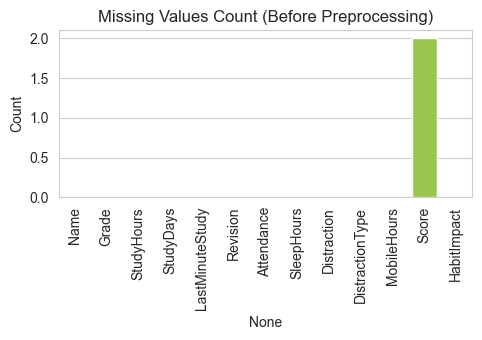

In [23]:
# Missing Values Visualization
plt.figure(figsize=(5, 3.5))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values, palette='viridis')
plt.title('Missing Values Count (Before Preprocessing)')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

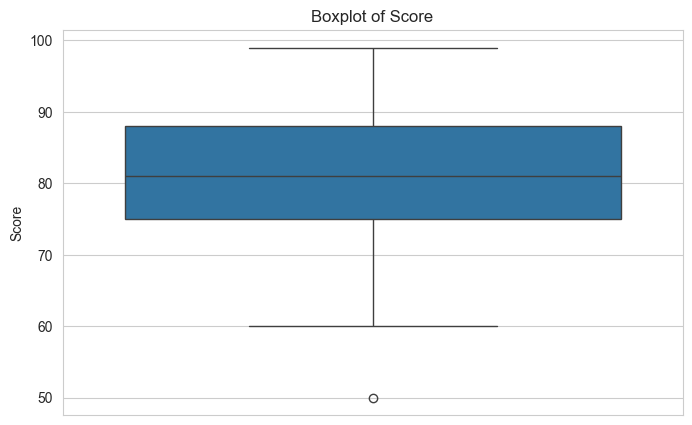

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Score'])
plt.title('Boxplot of Score')
plt.show()

In [25]:
print("Columns name:",df.columns)

Columns name: Index(['Name', 'Grade', 'StudyHours', 'StudyDays', 'LastMinuteStudy',
       'Revision', 'Attendance', 'SleepHours', 'Distraction',
       'DistractionType', 'MobileHours', 'Score', 'HabitImpact'],
      dtype='str')


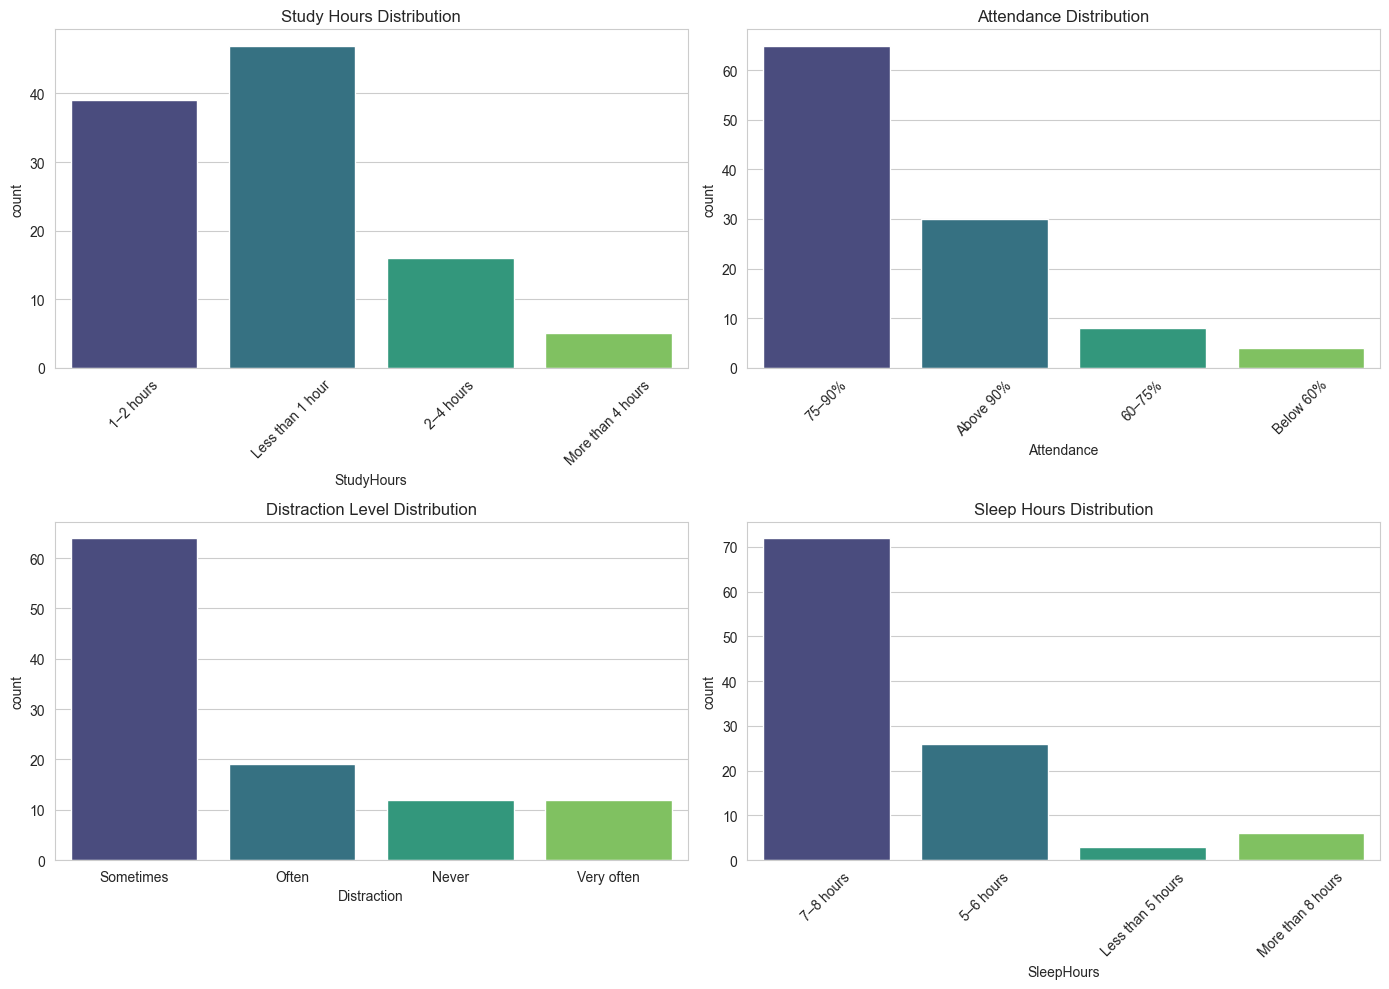

In [26]:
# Key Categorical Features Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='StudyHours', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Study Hours Distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(x='Attendance', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Attendance Distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(x='Distraction', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Distraction Level Distribution')

sns.countplot(x='SleepHours', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Sleep Hours Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [27]:
print('=== DATA PREPROCESSING STARTED ===')

# Fill missing Score with mean
df['Score'] = df['Score'].fillna(df['Score'].mean())

# Create Binary Target (2 Classes)
df['performance_class'] = (df['Score'] >= 80).astype(int)

print('New Binary Target Distribution:')
print(df['performance_class'].value_counts())
print('Class 1 = High Performance (≥80), Class 0 = Low Performance (<80)')

=== DATA PREPROCESSING STARTED ===
New Binary Target Distribution:
performance_class
1    66
0    41
Name: count, dtype: int64
Class 1 = High Performance (≥80), Class 0 = Low Performance (<80)


In [28]:
# Ordinal Encoding
study_hours_mapping = {'Less than 1 hour': 1, '1–2 hours': 2, '2–4 hours': 3, 'More than 4 hours': 4}
df['study_hours_encoded'] = df['StudyHours'].map(study_hours_mapping)

sleep_mapping = {'Less than 5 hours': 1, '5–6 hours': 2, '7–8 hours': 3, 'More than 8 hours': 4}
df['sleep_hours_encoded'] = df['SleepHours'].map(sleep_mapping)

attendance_mapping = {'Below 60%': 1, '60–75%': 2, '75–90%': 3, 'Above 90%': 4}
df['attendance_encoded'] = df['Attendance'].map(attendance_mapping)

distraction_map = {'Never': 0, 'Sometimes': 1, 'Often': 2, 'Very often': 3}
df['distracted_level'] = df['Distraction'].map(distraction_map)

# Engineered Features
df['distraction_impact'] = df['distracted_level'] * df['study_hours_encoded']
df['study_efficiency']   = df['study_hours_encoded'] * df['attendance_encoded']
df['study_quality']      = (df['study_hours_encoded'] + df['study_efficiency'] + df['attendance_encoded']) / 3

# Label Encoding remaining categorical columns
cat_cols_to_encode = ['StudyDays', 'LastMinuteStudy', 'Revision', 'DistractionType', 'MobileHours']
le = LabelEncoder()
for col in cat_cols_to_encode:
    df[col + '_encoded'] = le.fit_transform(df[col])

print('Feature encoding complete.')
print('New columns added:', [c for c in df.columns if '_encoded' in c or c in ['distracted_level','distraction_impact','study_efficiency','study_quality']])

Feature encoding complete.
New columns added: ['study_hours_encoded', 'sleep_hours_encoded', 'attendance_encoded', 'distracted_level', 'distraction_impact', 'study_efficiency', 'study_quality', 'StudyDays_encoded', 'LastMinuteStudy_encoded', 'Revision_encoded', 'DistractionType_encoded', 'MobileHours_encoded']


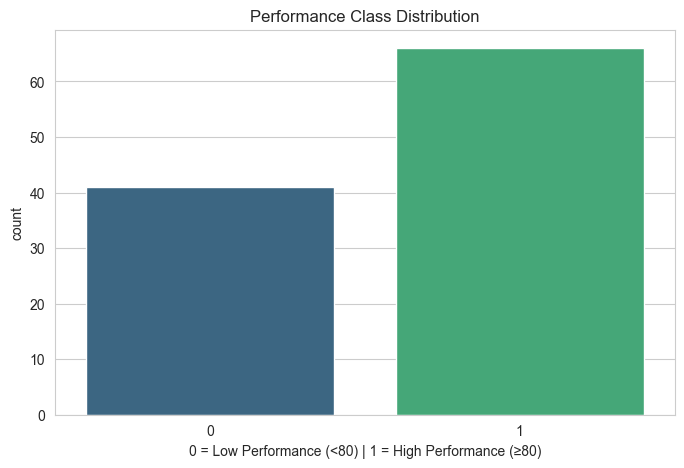

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(x='performance_class', data=df, palette='viridis')
plt.title('Performance Class Distribution')
plt.xlabel('0 = Low Performance (<80) | 1 = High Performance (≥80)')
plt.show()

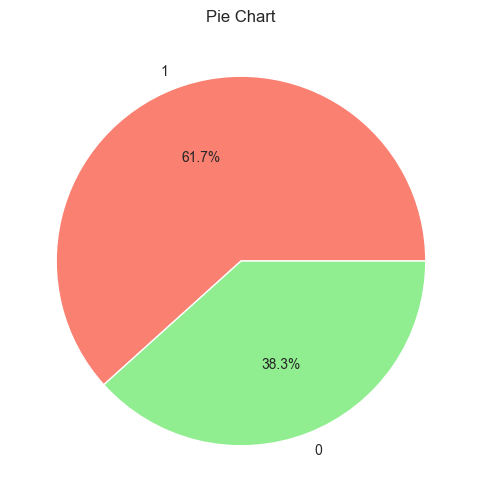

In [30]:
plt.figure(figsize=(6, 6))
df['performance_class'].value_counts().plot.pie(autopct='%1.1f%%', colors=['salmon', 'lightgreen'])
plt.title('Pie Chart')
plt.show()

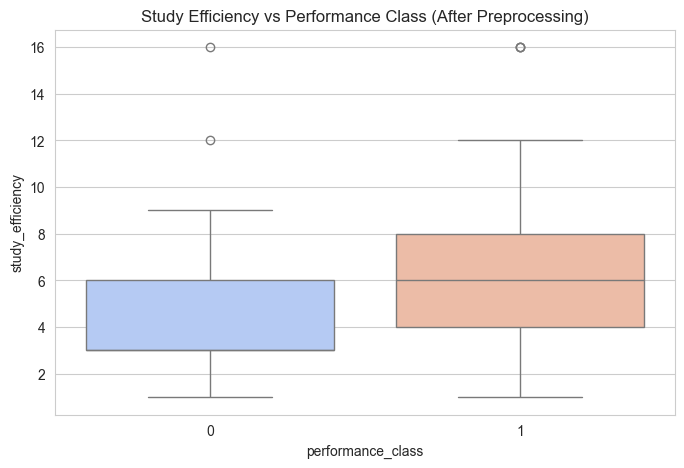

In [31]:
# Study Efficiency vs Performance
plt.figure(figsize=(8, 5))
sns.boxplot(x='performance_class', y='study_efficiency', data=df, palette='coolwarm')
plt.title('Study Efficiency vs Performance Class (After Preprocessing)')
plt.show()

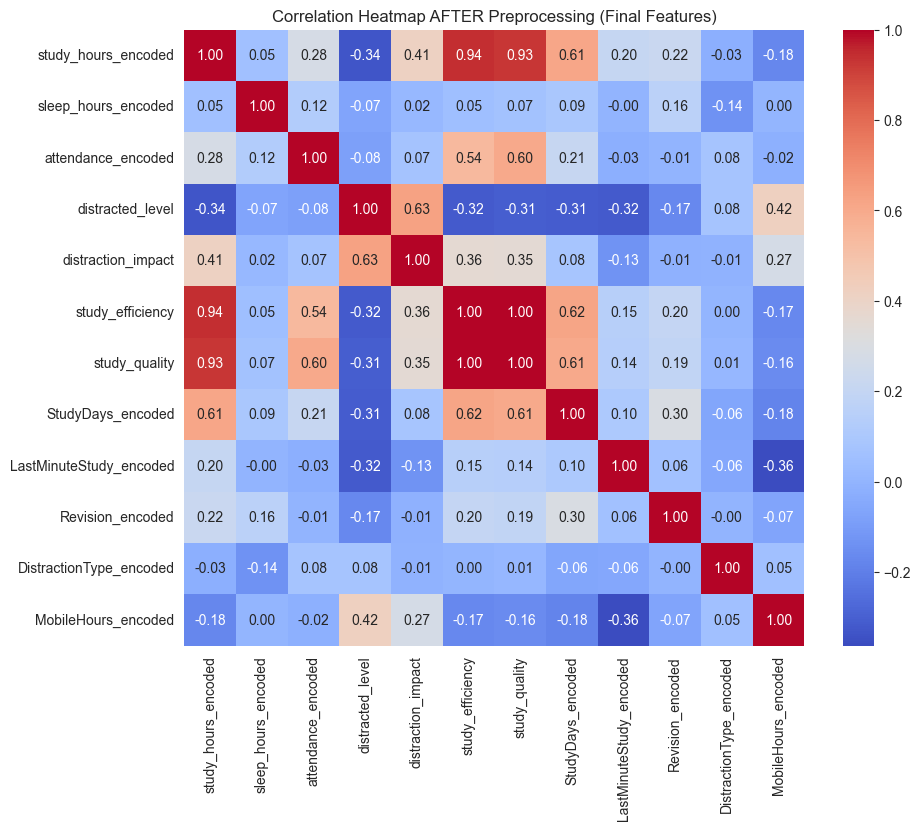

In [32]:
# Correlation Heatmap AFTER Preprocessing
drop_cols = ['Name', 'Grade', 'StudyHours', 'StudyDays', 'LastMinuteStudy', 'Revision',
             'Attendance', 'SleepHours', 'Distraction', 'DistractionType', 'MobileHours',
             'Score', 'HabitImpact']

X_temp = df.drop(drop_cols + ['performance_class'], axis=1)

plt.figure(figsize=(10, 8))
corr_final = X_temp.corr()
sns.heatmap(corr_final, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap AFTER Preprocessing (Final Features)')
plt.show()

In [33]:
drop_cols = ['Name', 'Grade', 'StudyHours', 'StudyDays', 'LastMinuteStudy', 'Revision',
             'Attendance', 'SleepHours', 'Distraction', 'DistractionType', 'MobileHours',
             'Score', 'HabitImpact']

X = df.drop(drop_cols + ['performance_class'], axis=1)
y = df['performance_class']

print('Final Feature Set Shape:', X.shape)
print('Features used:', list(X.columns))

Final Feature Set Shape: (107, 12)
Features used: ['study_hours_encoded', 'sleep_hours_encoded', 'attendance_encoded', 'distracted_level', 'distraction_impact', 'study_efficiency', 'study_quality', 'StudyDays_encoded', 'LastMinuteStudy_encoded', 'Revision_encoded', 'DistractionType_encoded', 'MobileHours_encoded']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train Shape:', X_train.shape)
print('Test Shape: ', X_test.shape)

Train Shape: (85, 12)
Test Shape:  (22, 12)


=== CLASS DISTRIBUTION ===
performance_class
1    66
0    41
Name: count, dtype: int64

Minority class ratio: 38.32%


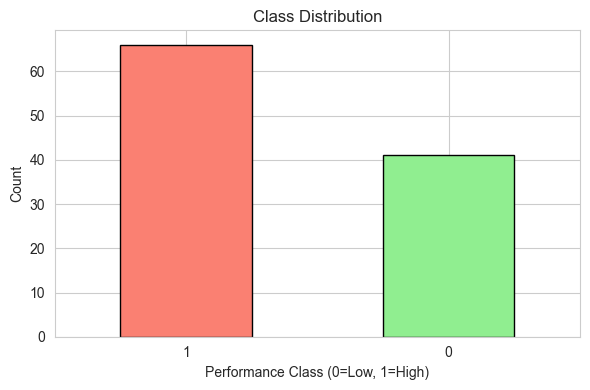


Classes are balanced.


In [35]:
print('=== CLASS DISTRIBUTION ===')
print(y.value_counts())
print(f'\nMinority class ratio: {y.value_counts(normalize=True).min():.2%}')

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Performance Class (0=Low, 1=High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Apply SMOTE only if imbalanced
if y.value_counts(normalize=True).min() < 0.35:
    from imblearn.over_sampling import SMOTE
    print('\nImbalance detected → Applying SMOTE...')
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f'After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')
else:
    X_train_res, y_train_res = X_train, y_train
    print('\nClasses are balanced.')

In [36]:
models = {
    'RandomForest':     RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM':              Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))]),
    'KNN':              Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
}

best_model = None
best_name  = ''
best_acc   = 0

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f'{name} → Accuracy: {acc:.4f}')

    if acc > best_acc:
        best_acc   = acc
        best_model = model
        best_name  = name

print(f'\n🏆 BEST MODEL: {best_name} with {best_acc:.4f} Accuracy')

RandomForest → Accuracy: 0.5000
GradientBoosting → Accuracy: 0.5000
SVM → Accuracy: 0.5909
KNN → Accuracy: 0.6364

🏆 BEST MODEL: KNN with 0.6364 Accuracy


In [37]:
# Full Metrics Table
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    proba  = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':        name,
        'Accuracy':     accuracy_score(y_test, y_pred),
        'F1 (macro)':   f1_score(y_test, y_pred, average='macro'),
        'F1 (class 0)': f1_score(y_test, y_pred, pos_label=0),
        'F1 (class 1)': f1_score(y_test, y_pred, pos_label=1),
        'Precision':    precision_score(y_test, y_pred, average='macro'),
        'Recall':       recall_score(y_test, y_pred, average='macro'),
        'AUC-ROC':      roc_auc_score(y_test, proba),
        'MCC':          matthews_corrcoef(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('\n=== FULL MODEL COMPARISON TABLE ===')
print(results_df.to_string())


=== FULL MODEL COMPARISON TABLE ===
                  Accuracy  F1 (macro)  F1 (class 0)  F1 (class 1)  Precision  Recall  AUC-ROC     MCC
Model                                                                                                 
RandomForest        0.5000      0.3995        0.1538        0.6452     0.3941  0.4196   0.3527 -0.1845
GradientBoosting    0.5000      0.3995        0.1538        0.6452     0.3941  0.4196   0.4107 -0.1845
SVM                 0.5909      0.5087        0.3077        0.7097     0.5235  0.5179   0.3929  0.0410
KNN                 0.6364      0.6239        0.5556        0.6923     0.6250  0.6339   0.5938  0.2588


In [38]:
# Best Model Detailed Classification Report
y_pred_best = best_model.predict(X_test)
print(f'=== DETAILED CLASSIFICATION REPORT: {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=['Low (0)', 'High (1)']))

=== DETAILED CLASSIFICATION REPORT: KNN ===
              precision    recall  f1-score   support

     Low (0)       0.50      0.62      0.56         8
    High (1)       0.75      0.64      0.69        14

    accuracy                           0.64        22
   macro avg       0.62      0.63      0.62        22
weighted avg       0.66      0.64      0.64        22



In [39]:
print("Accuracy:")
accuracy_score(y_test, y_pred_best)

Accuracy:


0.6363636363636364

=== EVALUATION METRICS ===
Accuracy  : 0.6364
Precision : 0.7500
Recall    : 0.6429
F1 Score  : 0.6923
ROC-AUC   : 0.5938
MCC       : 0.2588

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Low (0)       0.50      0.62      0.56         8
    High (1)       0.75      0.64      0.69        14

    accuracy                           0.64        22
   macro avg       0.62      0.63      0.62        22
weighted avg       0.66      0.64      0.64        22



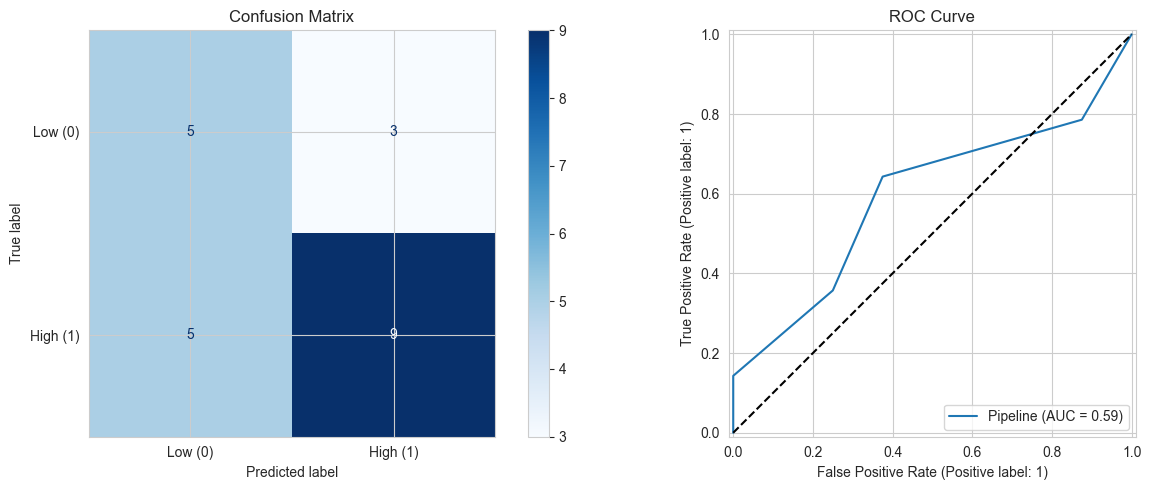

In [40]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report, matthews_corrcoef
)
# --- Predictions ---
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]  # probability for class 1 (High)

# --- 1. Core Metrics ---
print("=== EVALUATION METRICS ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"MCC       : {matthews_corrcoef(y_test, y_pred):.4f}")

# --- 2. Classification Report ---
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Low (0)', 'High (1)']))

# --- 3. Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Low (0)', 'High (1)'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# --- 4. ROC Curve ---
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0,1],[0,1],'k--')

plt.tight_layout()
plt.show()